In [36]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import os
from io import StringIO

%matplotlib inline

PATH = "/home/giulia/labprog/particle_mesh/"

def get_step(filename):
    base = os.path.basename(filename)
    nums = re.findall(r'\d+', base)
    return int(nums[-1]) if nums else -1

def load_clean_table(filename, expected_cols):
    """
    Legge un file numerico tenendo solo le righe con expected_cols colonne.
    Ignora righe vuote, commenti e righe iniziali 'sporche' tipo N_p o N_g.
    """
    valid_lines = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            parts = line.split()

            if len(parts) != expected_cols:
                continue

            try:
                [float(x) for x in parts]
                valid_lines.append(line)
            except ValueError:
                continue

    if not valid_lines:
        raise ValueError(f"Nessuna riga valida trovata in {filename} con {expected_cols} colonne")

    data = np.loadtxt(StringIO("\n".join(valid_lines)))

    if data.ndim == 1:
        data = data.reshape(1, -1)

    return data

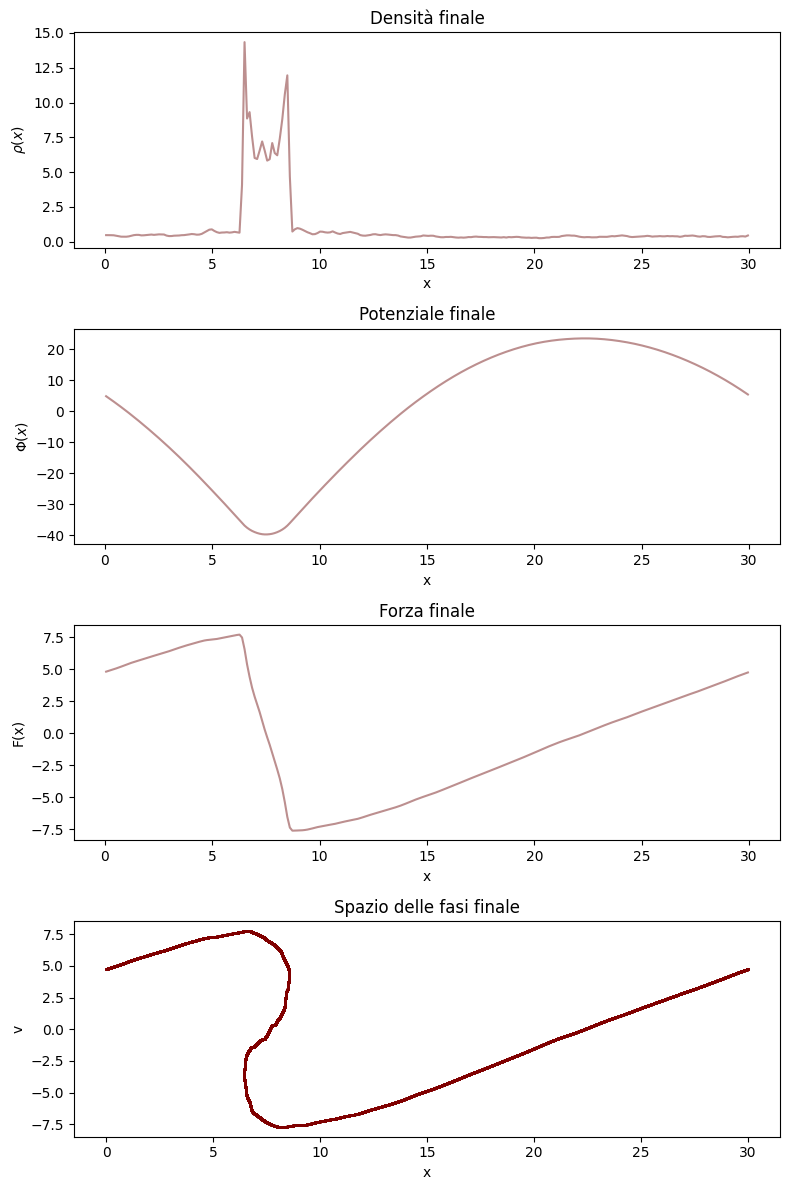

Grafico 1 salvato.


In [37]:
try:
    rho   = load_clean_table(os.path.join(PATH, "density_final.txt"), 2)
    pot   = load_clean_table(os.path.join(PATH, "potential_final.txt"), 2)
    force = load_clean_table(os.path.join(PATH, "force_final.txt"), 2)
    part  = load_clean_table(os.path.join(PATH, "final_particles.txt"), 3)

    part_x = part[:, 0]
    part_v = part[:, 1]
    part_m = part[:, 2]

    fig, axs = plt.subplots(4, 1, figsize=(8, 12))

    axs[0].plot(rho[:, 0], rho[:, 1], color='rosybrown')
    axs[0].set_title("Densità finale")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel(r"$\rho(x)$")

    axs[1].plot(pot[:, 0], pot[:, 1], color='rosybrown')
    axs[1].set_title("Potenziale finale")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel(r"$\Phi(x)$")

    axs[2].plot(force[:, 0], force[:, 1], color='rosybrown')
    axs[2].set_title("Forza finale")
    axs[2].set_xlabel("x")
    axs[2].set_ylabel("F(x)")

    axs[3].scatter(part_x, part_v, s=0.2, color='maroon', alpha=0.5)
    axs[3].set_title("Spazio delle fasi finale")
    axs[3].set_xlabel("x")
    axs[3].set_ylabel("v")

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "1_stato_finale.png"), dpi=200, bbox_inches="tight")
    plt.show()

    print("Grafico 1 salvato.")

except Exception as e:
    print(f"Errore Grafico 1: {e}")

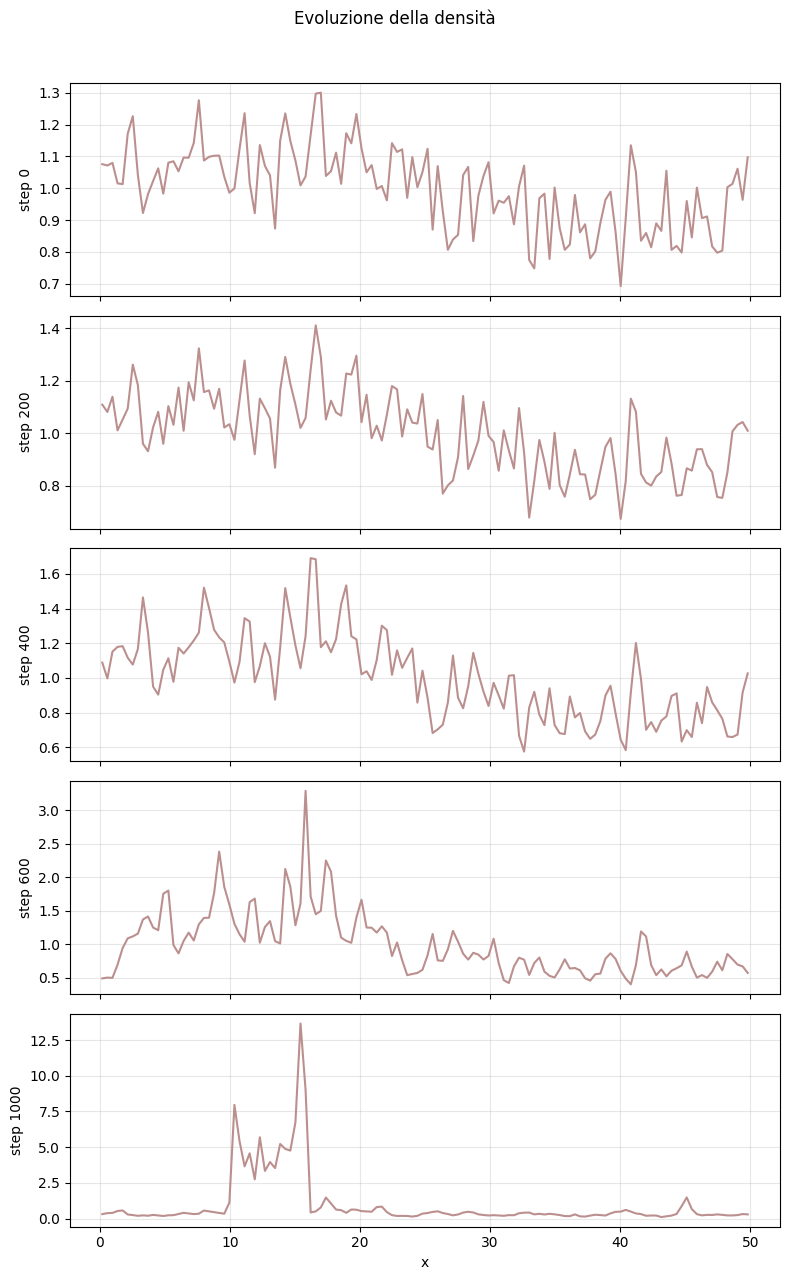

Grafico 2 salvato.


In [59]:
files_rho = sorted(
    glob.glob(os.path.join(PATH, "density_step_*.txt")),
    key=get_step
)

if len(files_rho) == 0:
    print("Nessun file density_step_*.txt trovato.")
else:
    nplot = min(5, len(files_rho))
    idx = np.linspace(0, len(files_rho) - 1, nplot, dtype=int)

    fig, axs = plt.subplots(nplot, 1, figsize=(8, 2.5 * nplot), sharex=True)
    if nplot == 1:
        axs = [axs]

    for i, f_idx in enumerate(idx):
        data = load_clean_table(files_rho[f_idx], 2)
        step = get_step(files_rho[f_idx])

        axs[i].plot(data[:, 0], data[:, 1], color='rosybrown')
        axs[i].set_ylabel(f"step {step}")
        axs[i].grid(alpha=0.3)

    axs[-1].set_xlabel("x")
    fig.suptitle("Evoluzione della densità", y=1.02)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "2_evoluzione_densita.png"), dpi=200, bbox_inches="tight")
    plt.show()

    print("Grafico 2 salvato.")

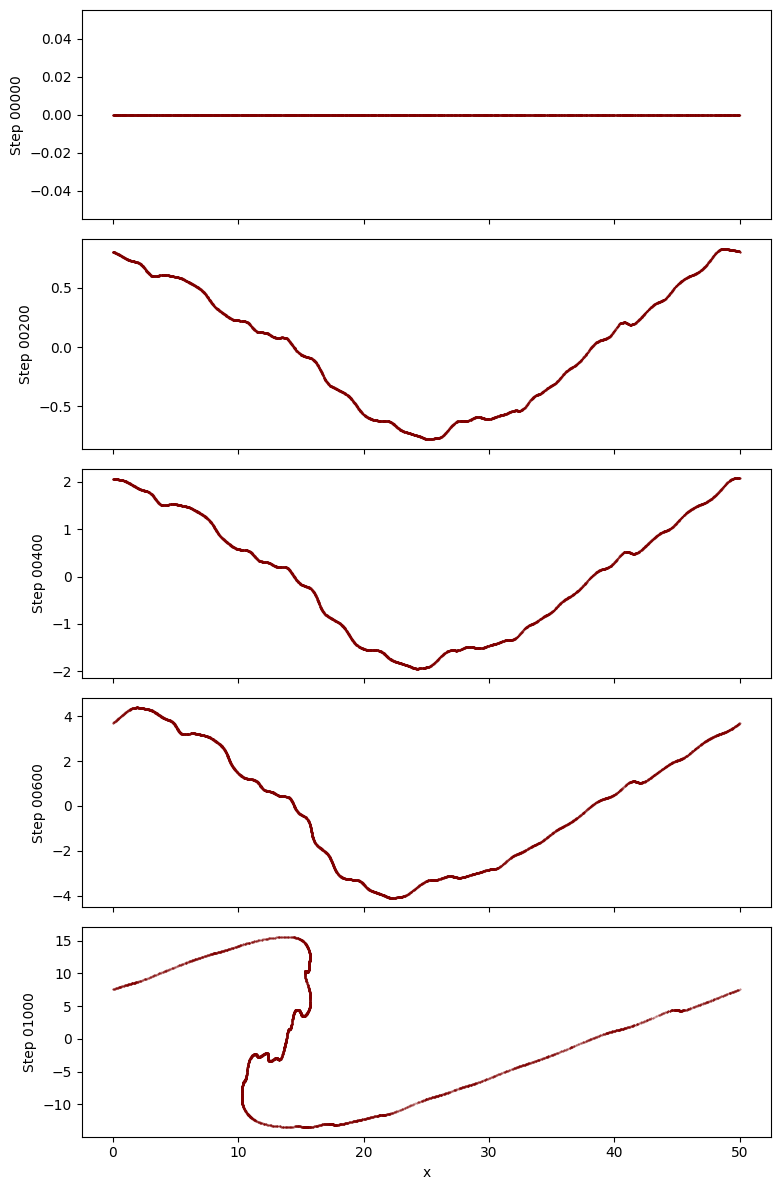

Grafico 3 salvato.


In [60]:
files_part = sorted(
    glob.glob(os.path.join(PATH, "particles_step_*.txt")),
    key=lambda x: int(re.findall(r'\d+', os.path.basename(x))[0])
)

if len(files_part) >= 5:
    idx = np.linspace(0, len(files_part) - 1, 5, dtype=int)
    fig, axs = plt.subplots(5, 1, figsize=(8, 12), sharex=True)

    for i, f_idx in enumerate(idx):
        pdata = np.loadtxt(files_part[f_idx], skiprows=1)

        px = pdata[:, 0]
        pv = pdata[:, 1]

        axs[i].scatter(px, pv, s=0.2, color='maroon', alpha=0.3)
        axs[i].set_ylabel(f"Step {re.findall(r'\d+', os.path.basename(files_part[f_idx]))[0]}")

    axs[-1].set_xlabel("x")
    plt.tight_layout()
    plt.savefig("3_evoluzione_distribuzione.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Grafico 3 salvato.")